In [1]:
import pandas as pd

df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

print(df.head())
print(df.shape)

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns 


In [24]:
import os
os.makedirs("outputs", exist_ok=True)

In [3]:
print(df.head())

print(df.shape)

print(df.columns)

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

In [4]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   267 non-null    str    
 1   Date                                     267 non-null    str    
 2   Frequency                                267 non-null    str    
 3   Estimated Unemployment Rate (%)          267 non-null    float64
 4   Estimated Employed                       267 non-null    int64  
 5   Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                 267 non-null    str    
 7   longitude                                267 non-null    float64
 8   latitude                                 267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 26.0 KB


In [6]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

In [7]:
print(df.dtypes)

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Region.1                                              str
longitude                                         float64
latitude                                          float64
dtype: object


In [8]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


In [9]:
state_unemp = (
    df.groupby("Region")
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

print(state_unemp)

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64


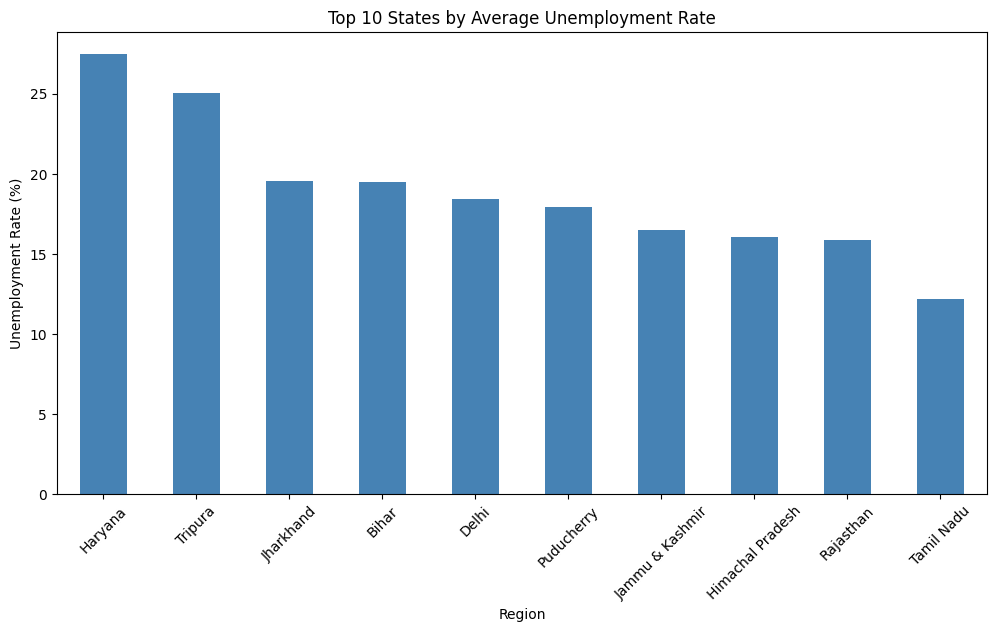

In [10]:
plt.figure(figsize=(12,6))

state_unemp.head(10).plot(
    kind="bar",
    color="steelblue"
)

plt.title(
    "Top 10 States by Average Unemployment Rate"
)

plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

In [25]:
plt.savefig(
    "outputs/chart_name.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [38]:
import os

print(os.getcwd())
print(os.path.exists("outputs"))

c:\Users\jishn\Desktop\Unemployment Analysis
True


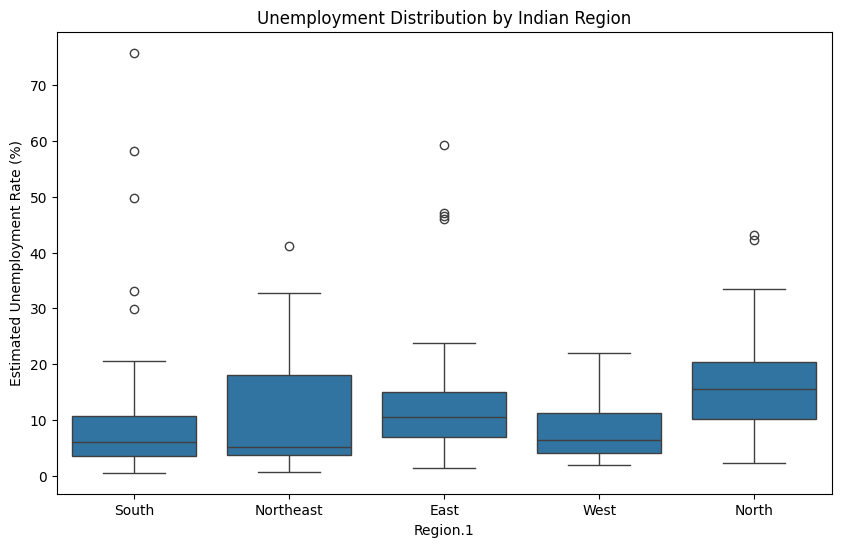

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Region.1",
    y="Estimated Unemployment Rate (%)",
    data=df
)

plt.title(
    "Unemployment Distribution by Indian Region"
)

plt.show()

In [26]:
plt.savefig(
    "outputs/chart_name.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

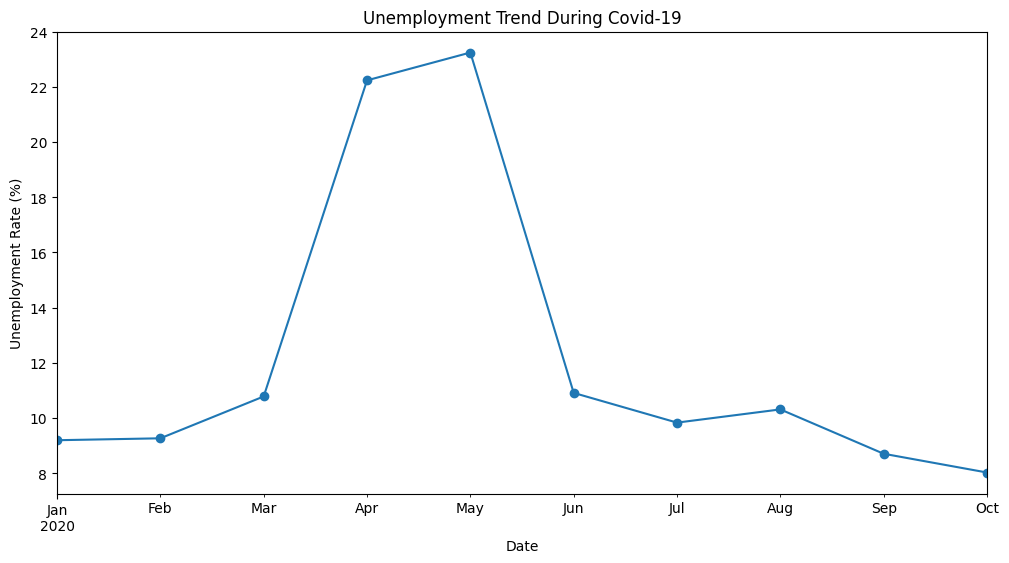

In [12]:
monthly = (
    df.groupby("Date")
    ["Estimated Unemployment Rate (%)"]
    .mean()
)

plt.figure(figsize=(12,6))

monthly.plot(
    marker="o"
)

plt.title(
    "Unemployment Trend During Covid-19"
)

plt.ylabel(
    "Unemployment Rate (%)"
)

plt.show()

In [27]:
plt.savefig(
    "outputs/chart_name.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

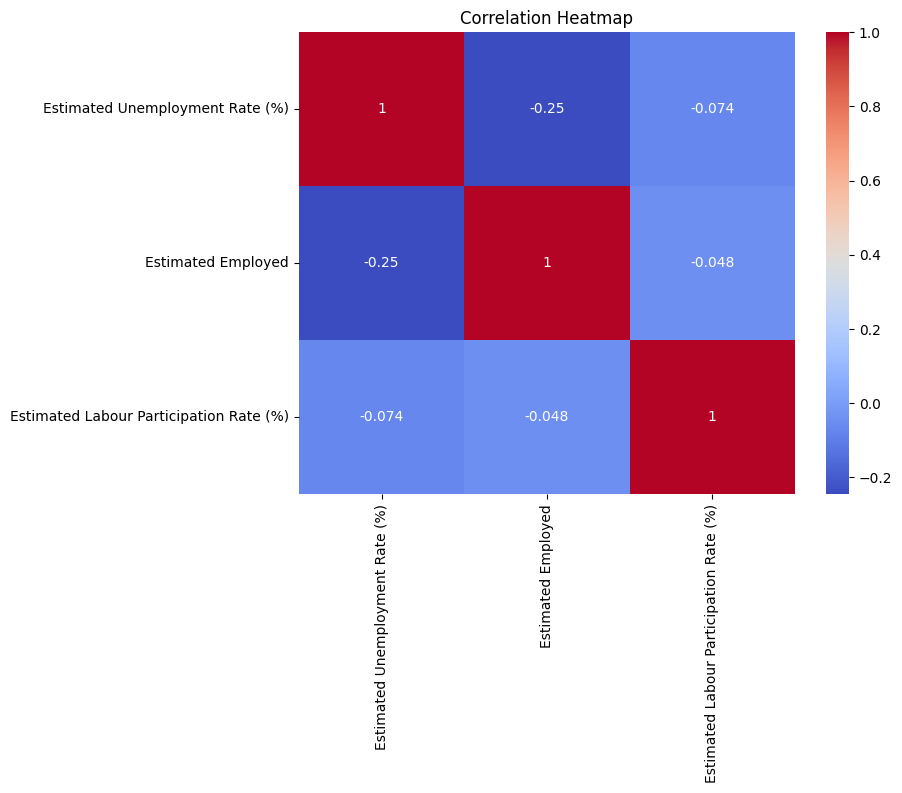

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[
        [
            "Estimated Unemployment Rate (%)",
            "Estimated Employed",
            "Estimated Labour Participation Rate (%)"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [28]:
plt.savefig(
    "outputs/chart_name.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

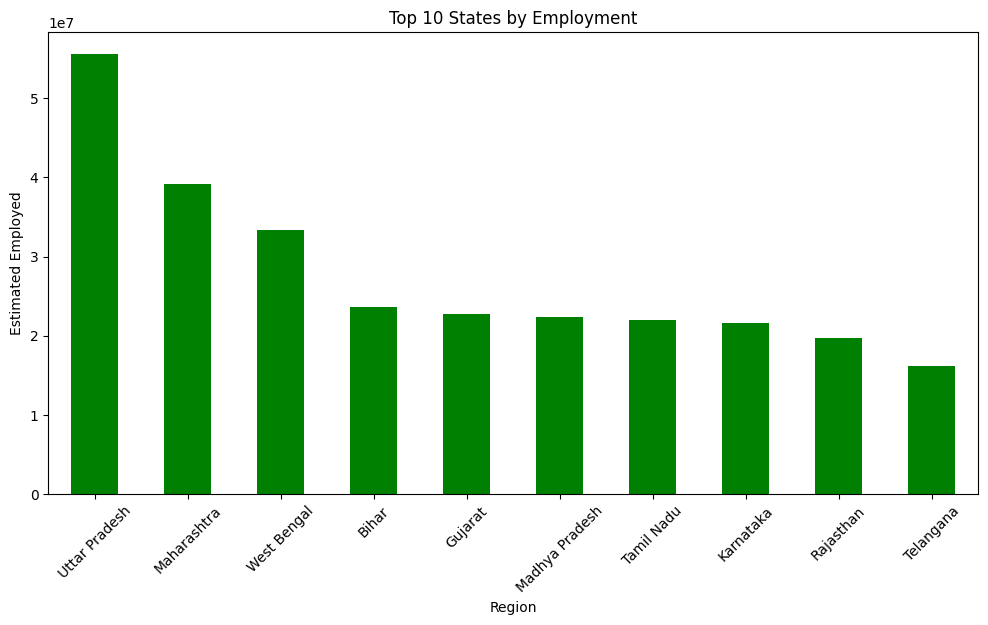

In [14]:
state_emp = (
    df.groupby("Region")
    ["Estimated Employed"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

state_emp.head(10).plot(
    kind="bar",
    color="green"
)

plt.title("Top 10 States by Employment")

plt.ylabel("Estimated Employed")

plt.xticks(rotation=45)

plt.show()

In [29]:
plt.savefig(
    "outputs/chart_name.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

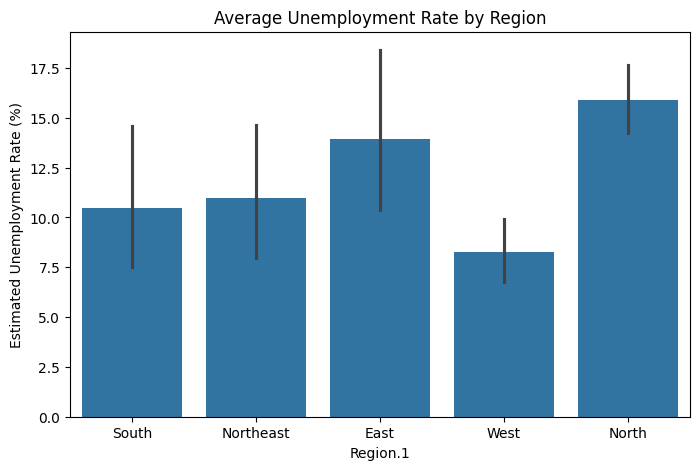

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Region.1",
    y="Estimated Unemployment Rate (%)",
    data=df,
    estimator="mean"
)

plt.title(
    "Average Unemployment Rate by Region"
)

plt.show()

In [30]:
plt.savefig(
    "outputs/chart_name.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [19]:
import plotly.express as px

fig = px.scatter_geo(
    df,
    lat="longitude",  
    lon="latitude",   
    color="Estimated Unemployment Rate (%)",
    size="Estimated Unemployment Rate (%)",
    hover_name="Region",
    title="Unemployment Rate Across India",
    color_continuous_scale="Reds",
    size_max=30
)

fig.update_geos(
    center=dict(lat=20.5937, lon=78.9629),
    projection_scale=4,
    scope="asia",
    showland=True,
    landcolor="lightgray",
    showocean=True,
    oceancolor="lightblue"
)

fig.write_html("unemployment_map.html")
print("Map saved!")

Map saved!


In [20]:
print(df[["Region", "latitude", "longitude"]].drop_duplicates())


               Region  latitude  longitude
0      Andhra Pradesh   79.7400    15.9129
10              Assam   92.9376    26.2006
20              Bihar   85.3131    25.0961
30       Chhattisgarh   81.8661    21.2787
40              Delhi   77.1025    28.7041
50                Goa   74.1240    15.2993
60            Gujarat   71.1924    22.2587
70            Haryana   76.0856    29.0588
80   Himachal Pradesh   77.1734    31.1048
90    Jammu & Kashmir   76.5762    33.7782
99          Jharkhand   85.2799    23.6102
109         Karnataka   75.7139    15.3173
119            Kerala   76.2711    10.8505
129    Madhya Pradesh   78.6569    22.9734
139       Maharashtra   75.7139    19.7515
149         Meghalaya   91.3662    25.4670
159            Odisha   85.0985    20.9517
169        Puducherry   79.8083    11.9416
179            Punjab   75.3412    31.1471
189         Rajasthan   74.2179    27.0238
199            Sikkim   88.5122    27.5330
207        Tamil Nadu   78.6569    11.1271
217        

In [21]:
fig.write_html("unemployment_map.html")

In [22]:
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [33]:
import pandas as pd

covid_date = pd.Timestamp("2020-03-01")

df["Period"] = df["Date"].apply(
    lambda x: "Post Covid" if x >= covid_date else "Pre Covid"
)

covid_comparison = df.groupby("Period")["Estimated Unemployment Rate (%)"].mean()
print(covid_comparison)

Period
Post Covid    12.963860
Pre Covid      9.231346
Name: Estimated Unemployment Rate (%), dtype: float64


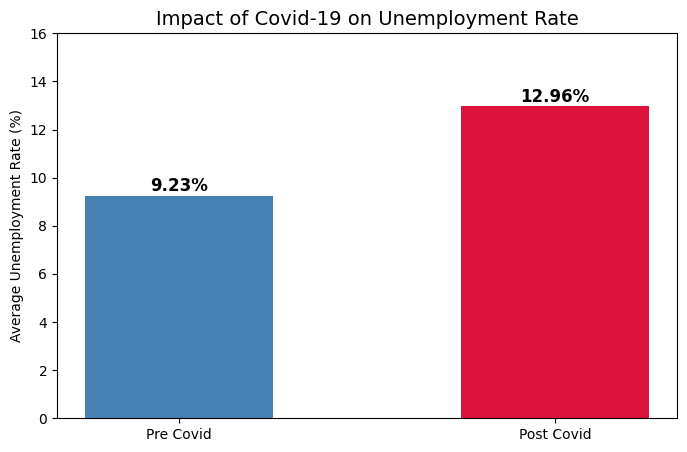

Chart saved!


In [36]:
covid_comparison = covid_comparison.reindex(["Pre Covid", "Post Covid"])
plt.figure(figsize=(8,5))
bars = plt.bar(
    covid_comparison.index,
    covid_comparison.values,
    color=["steelblue", "crimson"],
    width=0.5
)

for bar, value in zip(bars, covid_comparison.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f"{value:.2f}%",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Impact of Covid-19 on Unemployment Rate", fontsize=14)
plt.ylabel("Average Unemployment Rate (%)")
plt.ylim(0, 16)
plt.savefig("outputs/covid_comparison.png", bbox_inches="tight", dpi=300)
plt.show()
print("Chart saved!")

In [35]:
plt.savefig(
    "outputs/chart_name.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

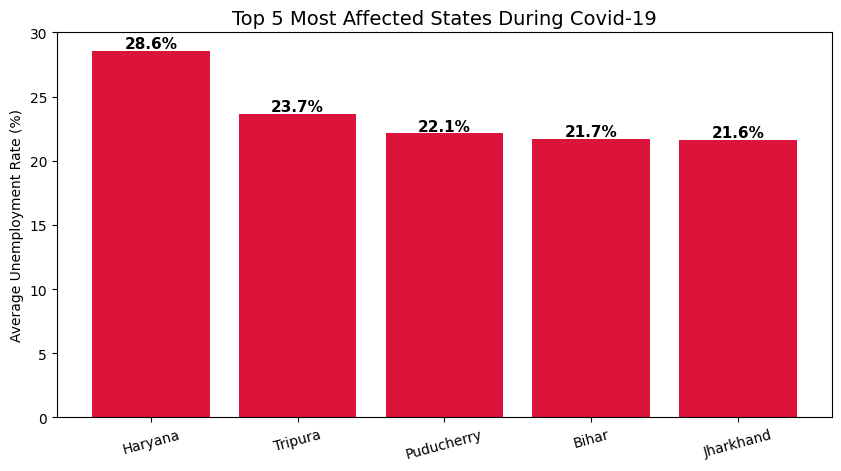

Chart saved!


In [37]:
top5_states = (
    df[df["Period"] == "Post Covid"]
    .groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,5))
bars = plt.bar(
    top5_states.index,
    top5_states.values,
    color="crimson"
)

for bar, value in zip(bars, top5_states.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f"{value:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Top 5 Most Affected States During Covid-19", fontsize=14)
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=15)
plt.savefig("outputs/top5_affected_states.png", bbox_inches="tight", dpi=300)
plt.show()
print("Chart saved!")